TokaMaker Example: WHAM mirror equilibrium {#doc_tMaker_wham_ex2}
==========
In this example we demonstrate how to create a simple WHAM-like axisymmetric mirror equilibrium [[D. Endrizzi et al. (2023)](https://doi.org/10.1017/S0022377823000806)] for cases with isotropic and anisotropic pressure [[S. Frank et al. (2026)](https://doi.org/10.1063/5.0306291)].

This example utilizes the mesh built in \ref doc_tMaker_wham_ex1.

**Warning:** Mirror equilibrium support is still in development. Please be careful when using this feature and report any issues.

**Note:** Running this example requires the [h5py](https://www.h5py.org/) python package, which is installable using `pip` or other standard methods.

In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import h5py
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun
from OpenFUSIONToolkit.util import mu0

## Setup calculation

### Initialize TokaMaker object
We now create a \ref OpenFUSIONToolkit.OFT_env "OFT_env" instance for execution using two threads and a \ref OpenFUSIONToolkit.TokaMaker.TokaMaker "TokaMaker" instance to use for equilibrium calculations.

In [3]:
myOFT = OFT_env(nthreads=4)
mygs = TokaMaker(myOFT)

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.9
Development branch:  tMaker_mirror
Revision id:         39333844

Parallelization Info:
  # of MPI tasks      =    1
  # of NUMA nodes     =    1
  # of OpenMP threads =    4

Linear Algebra backend: native

#----------------------------------------------



### Load mesh into TokaMaker
Now we load the mesh generated in \ref doc_tMaker_mirror_ex1 using \ref OpenFUSIONToolkit.TokaMaker.load_gs_mesh "load_gs_mesh()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_mesh "setup_mesh". Then we use \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_regions "setup_regions()", passing the conductor and coil dictionaries for the mesh, to define the different region types. Finally, we call \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup "setup()" to setup the required solver objects. During this call we can specify the desired element order (min=2, max=4).

**Note:** We also need to set `settings.mirror_mode=True` to set mirror specific options for TokaMaker.

In [4]:
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('WHAM_mesh.h5')
mygs.settings.mirror_mode=True
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order=2)


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  6.325E+00
    # of points  =   25253
    # of edges   =   74886
    # of cells   =   49634
    # of boundary points =     870
    # of boundary edges  =     870
    # of boundary cells  =     866
  Resolution statistics:
    hmin =  1.806E-03
    hrms =  1.741E-02
    hmax =  1.131E-01
  Surface grounded at vertex    9194


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 


 Inverting real matrix
   Time =   0.19251199999999999     


### Solve for vacuum field
To begin we compute the vacuum field using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.vac_solve "vac_solve()" with maximum nominal current in the mirror coils and zero current in the central coils.

   1  2.4912E+02
|B_throat| =  17.126 (nominal: 17.1)
|B_mid|    =   0.267 (nominal: 0.27)
Mirror ratio on axis =  64.118


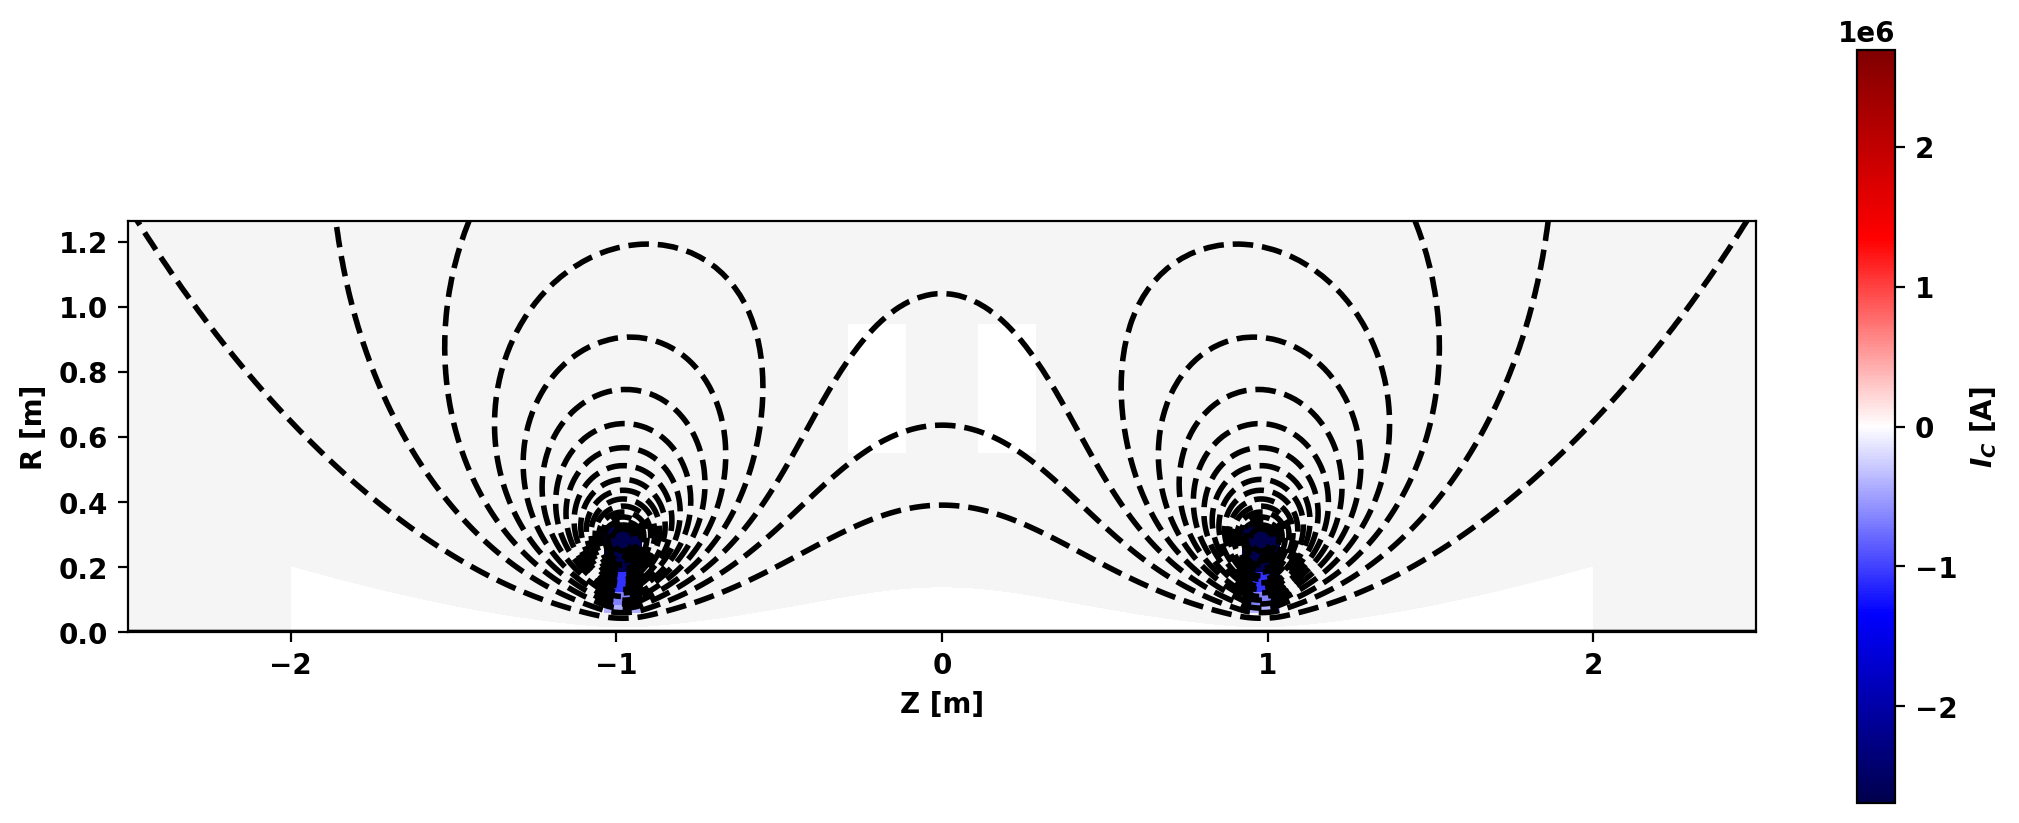

In [5]:
mygs.set_coil_currents({'mirror': -1.0, 'central': 0.0})
EQ_vac = mygs.vac_solve()
psi_vac = EQ_vac.get_psi(False)

# Plot field
fig, ax = plt.subplots(1,1,sharey=True,figsize=(10,4),constrained_layout=True)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,limiter_color=None)
mygs.plot_psi(fig,ax,psi=psi_vac,normalized=False,plasma_nlevels=20,plasma_color='k',vacuum_levels=None,xpoint_color=None,opoint_color=None)
ax.set_xlabel('Z [m]')
ax.set_ylabel('R [m]')

# Get B-field at midplane and mirror throat
mygs.set_psi(psi_vac)
field_eval = mygs.get_field_eval('B')
B_throat = field_eval.eval(np.r_[1.E-3,0.98])
B_midplane = field_eval.eval(np.r_[1.E-3,0.0])
print('|B_throat| = {0:7.3f} (nominal: 17.1)'.format(abs(B_throat[2])))
print('|B_mid|    = {0:7.3f} (nominal: 0.27)'.format(abs(B_midplane[2])))
print('Mirror ratio on axis = {0:7.3f}'.format(abs(B_throat[2]/B_midplane[2])))

### Define flux functions
We now define simple profiles for $P'$ of the form $((1-\hat{\psi})^{\alpha})^{\gamma}$ using \ref OpenFUSIONToolkit.TokaMaker.util.create_power_flux_fun "create_power_flux_fun()" where $\alpha$ and $\gamma$ can be adjusted to provide peaked and broad profiles respectively.

**Note:** Standard mirrors like WHAM only have diamagnetic current, therefore the scale factor of $F*F'$ will always be zero so we do not need to specify an $F*F'$ profile.

In [6]:
pp_prof = create_power_flux_fun(40,4.0,1.0)

mygs.set_profiles(pp_prof=pp_prof)

### Perform equilibrium solve
Now we solve for the resulting equilibrium, by first initializing a vacuum state (very low $I_p$) and then solving with a given target pressure at the geometric axis.

In [7]:
# Initialize with some tiny current (vacuum flux is all we really need)
mygs.set_targets(Ip=1.E-6)
err_flag = mygs.init_psi()
psi_init = mygs.get_psi()

# Force scale of F*F' to be zero and adjust solver tolerance
mygs.alam=0.0
mygs.settings.nl_tol=1.E-7
mygs.update_settings()

# Solve with real target
mygs.set_targets(pax=3.2E3)
EQ_iso = mygs.solve()

Starting non-linear GS solver
     1  0.0000E+00  2.0224E+00  1.2997E-04  5.0000E-02  0.0000E+00  0.0000E+00
     2  0.0000E+00  2.0227E+00  3.1710E-05  5.0000E-02  0.0000E+00  0.0000E+00
     3  0.0000E+00  2.0227E+00  8.0614E-06  5.0000E-02  0.0000E+00  0.0000E+00
     4  0.0000E+00  2.0227E+00  2.1040E-06  5.0000E-02  0.0000E+00  0.0000E+00
     5  0.0000E+00  2.0227E+00  5.5640E-07  5.0000E-02  0.0000E+00  0.0000E+00
     6  0.0000E+00  2.0227E+00  1.4787E-07  5.0000E-02  0.0000E+00  0.0000E+00
     7  0.0000E+00  2.0227E+00  3.9328E-08  5.0000E-02  0.0000E+00  0.0000E+00
 Timing:  0.20733600005041808     
   Source:    0.11040800029877573     
   Solve:      7.7778999926522374E-002
   Boundary:   1.2039998546242714E-003
   Other:      1.7944999970495701E-002


### Print information and plot equilibrium
Since most of the current generating the poloidal field is in the dipole, not the plasma itself we use `beta_Ip` to override the current in calculations of $\beta$.

We also compare the flux surfaces in vacuum (red) and with plasma pressure/current (black).

Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    2.5253E+04
  Current Centroid [m]    =    0.083 -0.000
  Plasma Volume [m^3]     =    0.121
  Peak Pressure [Pa]      =    3.1960E+03
  Stored Energy [J]       =    2.4714E+02
  Diamagnetic flux [Wb]   =    0.0000E+00
  Toroidal flux [Wb]      =    0.0000E+00
|B_throat| =  17.126 (nominal: 17.1)
|B_mid|    =   0.252 (nominal: 0.27)
Mirror ratio on axis =  67.843


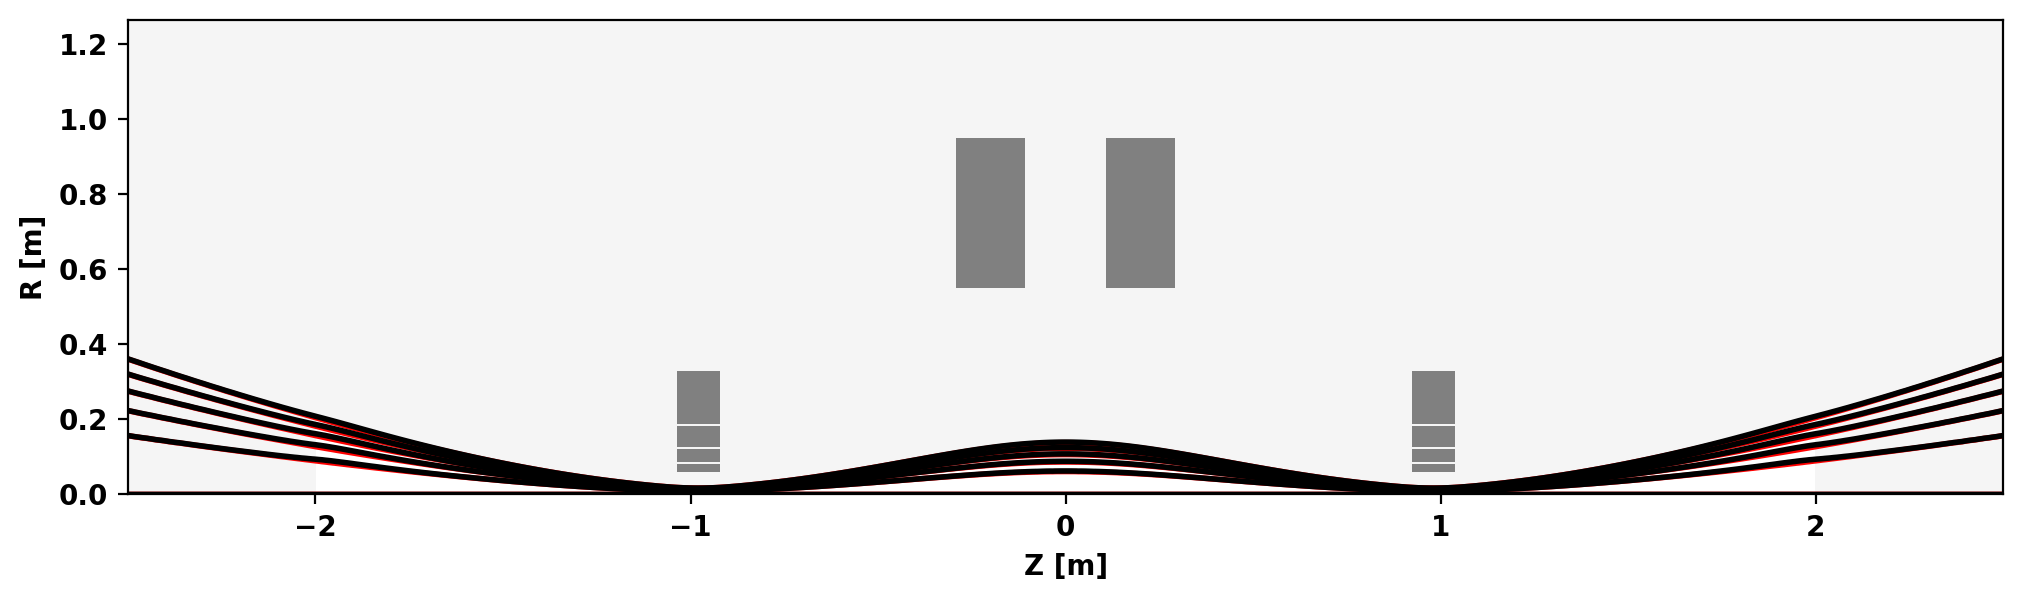

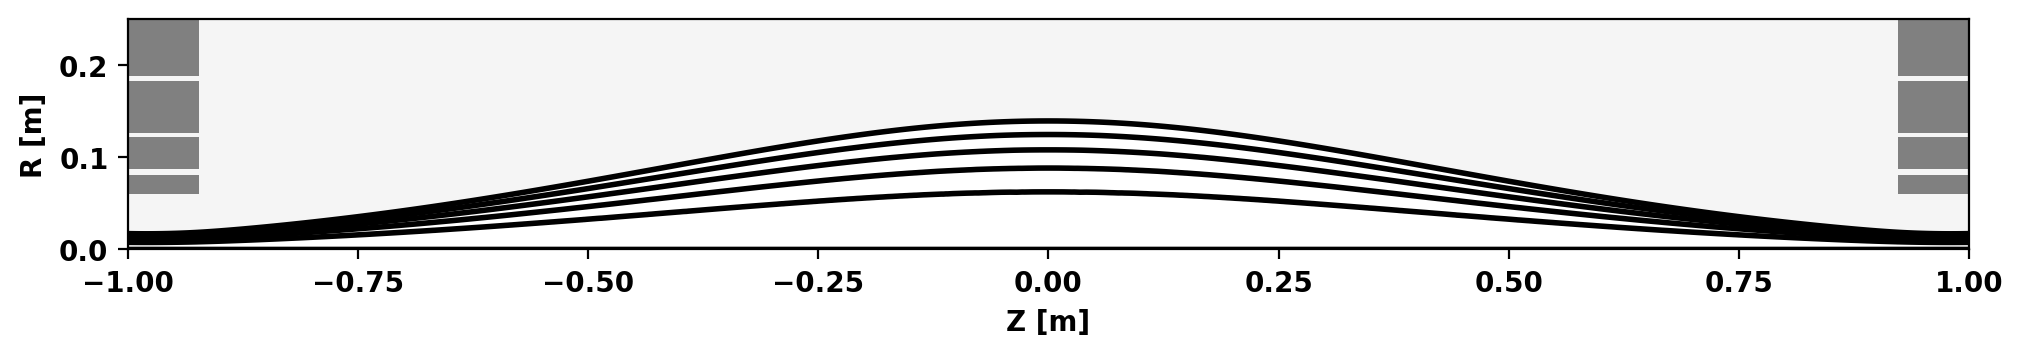

In [8]:
# Full machine plot
fig, ax = plt.subplots(1,1,sharey=True,figsize=(10,6),constrained_layout=True)
mygs.plot_machine(fig,ax,limiter_color=None)
mygs.plot_psi(fig,ax,psi=psi_init,plasma_nlevels=6,plasma_color='r',vacuum_nlevels=0,xpoint_color=None,opoint_color=None)
mygs.plot_psi(fig,ax,plasma_nlevels=6,plasma_color='k',vacuum_nlevels=0,xpoint_color='tab:green',opoint_color=None)
ax.set_xlabel('Z [m]')
_ = ax.set_ylabel('R [m]')

# Zoomed in plot
fig, ax = plt.subplots(1,1,sharey=True,figsize=(10,6),constrained_layout=True)
mygs.plot_machine(fig,ax,limiter_color=None)
mygs.plot_psi(fig,ax,plasma_nlevels=6,plasma_color='k',vacuum_nlevels=0,xpoint_color='tab:green',opoint_color=None)
ax.set_ylim(0.0,0.25)
ax.set_xlim(-1.0,1.0)
ax.set_xlabel('Z [m]')
ax.set_ylabel('R [m]')

# Print EQ information
mygs.print_info()

# Get B-fields
field_eval = mygs.get_field_eval('B')
B_throat = field_eval.eval(np.r_[1.E-3,0.98])
B_midplane = field_eval.eval(np.r_[1.E-3,0.0])
print('|B_throat| = {0:7.3f} (nominal: 17.1)'.format(abs(B_throat[2])))
print('|B_mid|    = {0:7.3f} (nominal: 0.27)'.format(abs(B_midplane[2])))
print('Mirror ratio on axis = {0:7.3f}'.format(abs(B_throat[2]/B_midplane[2])))

We can also plot the toroidal current distribution within the plasma using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_jtor_plasma "get_jtor_plasma()".

Starting CG solver
     0  0.000000E+00  0.000000E+00  5.818052E-04
     1 -2.094348E-03  9.306614E+00  6.494925E-05  6.978827E-06
     2 -2.224998E-03  1.117451E+01  2.699605E-05  2.415859E-06
     3 -2.229412E-03  1.135447E+01  4.293614E-06  3.781431E-07
     4 -2.229625E-03  1.136343E+01  1.692516E-06  1.489442E-07
     5 -2.229651E-03  1.136698E+01  4.630798E-07  4.073903E-08
     6 -2.229654E-03  1.136749E+01  1.860170E-07  1.636395E-08
     7 -2.229654E-03  1.136776E+01  6.155759E-08  5.415102E-09
     8 -2.229654E-03  1.136773E+01  2.552645E-08  2.245519E-09
     9 -2.229654E-03  1.136772E+01  9.453814E-09  8.316371E-10
    10 -2.229654E-03  1.136770E+01  3.383733E-09  2.976620E-10


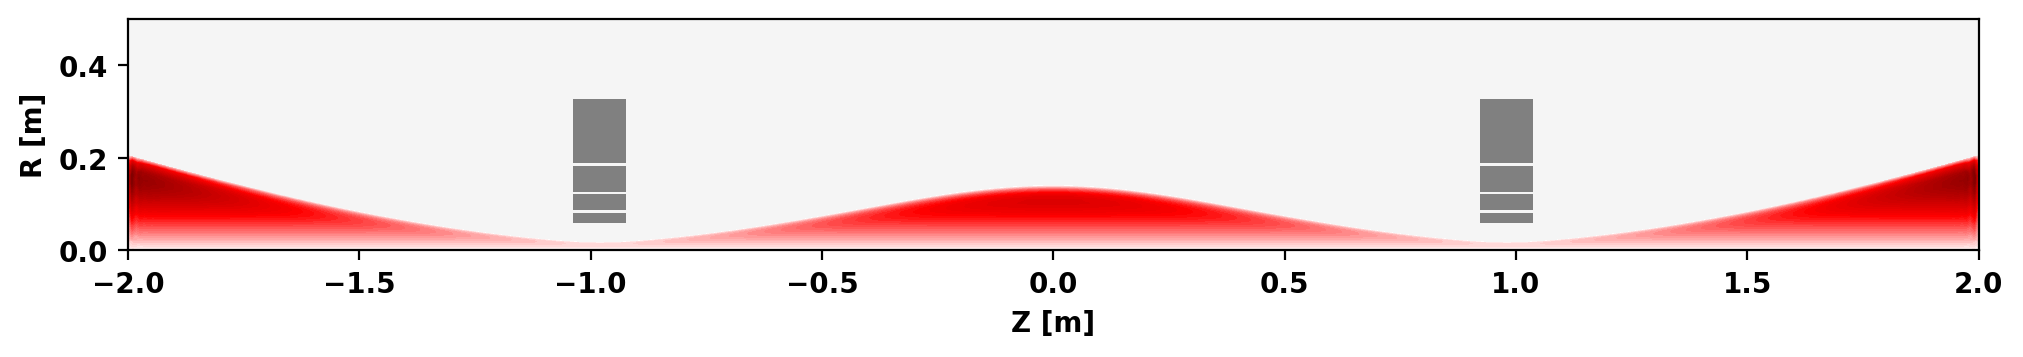

In [9]:
fig, ax = plt.subplots(1,1,sharey=True,figsize=(10,6),constrained_layout=True)
mygs.plot_machine(fig,ax,coil_colormap=None,limiter_color=None)
curr = EQ_iso.calc_jtor_plasma()
mask = (mygs.reg == 1)
vmax = (abs(curr)).max()
ax.tricontourf(mygs.r[:,1],mygs.r[:,0],mygs.lc[mask],curr,np.linspace(-vmax,vmax,80),cmap='seismic')
ax.set_ylim(0.0,0.5)
ax.set_xlim(-2.0,2.0)
ax.set_xlabel('Z [m]')
_ = ax.set_ylabel('R [m]')

### Re-solve with sloshing ions pressure profile
Now we re-solve the equilibrium using a "sloshing-ions" pressure profile, which includes anisotropic pressure effects [[S. Frank et al. (2026)](https://doi.org/10.1063/5.0306291)]. This profile takes the form

$$
P_{\parallel}(\psi, \textbf{r}) = P(\psi) \bar{b}/n(1-\bar{b})^n;
$$

$$
P_{\perp}(\psi, \textbf{r}) = P(\psi) \bar{b}^2(1-\bar{b})^{n-1},
$$

where $P(\psi)$ is the usual isotropic pressure profile set via \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_profiles "set_profiles()" and $\bar{b}(\textbf{r}) = \frac{B(\textbf{r})}{B_{Turn}(\psi)}$ is the normalized field relative to the turning point, which is in turn specified relative to the minimum field amplitude on each field line ($B_{Turn} = f_{Turn} B_0$).

This pressure profile can be activated using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_profiles "set_profiles()", which takes the turning point factor ($f_{Turn}$) and anisotropy exponent $n$ as inputs.

**Note:** The function currently assumes an axially symmetric mirror about $Z = 0$, with a specified mirror throat position used to isolate pressure to the central cell. In the future this constraint will be generalized to support a wider variety of mirror configurations. 

In [10]:
# Activate anisotropic profile with f_turn = 2.0, n = 2.0, and z_throat = 0.98
mygs.set_mirror_slosh(2.0,2.0,0.98)
mygs.set_targets(pax=2.788E4)
mygs.settings.maxits=10
mygs.update_settings()
EQ_slosh = mygs.solve()

Starting non-linear GS solver
     1  0.0000E+00  1.7623E+01  1.0419E-04  5.0000E-02  0.0000E+00  0.0000E+00
     2  0.0000E+00  1.7621E+01  2.0877E-05  5.0000E-02  0.0000E+00  0.0000E+00
     3  0.0000E+00  1.7621E+01  4.1877E-06  5.0000E-02  0.0000E+00  0.0000E+00
     4  0.0000E+00  1.7621E+01  8.4165E-07  5.0000E-02  0.0000E+00  0.0000E+00
     5  0.0000E+00  1.7621E+01  1.6952E-07  5.0000E-02  0.0000E+00  0.0000E+00
     6  0.0000E+00  1.7621E+01  3.4579E-08  5.0000E-02  0.0000E+00  0.0000E+00
 Timing:   3.9176880000159144     
   Source:     3.8235979998717085     
   Solve:      5.9556000283919275E-002
   Boundary:   9.1099995188415051E-004
   Other:      3.3622999908402562E-002


Plotting the toroidal current distribution within the plasma for the updated equilibrium shows the localization of current away toward the center of the cell.

Starting CG solver
     0  0.000000E+00  0.000000E+00  3.010684E-04
     1 -7.469609E-04  5.610548E+00  3.360318E-05  5.989287E-06
     2 -7.954329E-04  6.818325E+00  9.474448E-06  1.389556E-06
     3 -7.962671E-04  6.870668E+00  2.050283E-06  2.984110E-07
     4 -7.963392E-04  6.876198E+00  6.446127E-07  9.374551E-08
     5 -7.963446E-04  6.877471E+00  2.194752E-07  3.191219E-08
     6 -7.963453E-04  6.877711E+00  6.492364E-08  9.439715E-09
     7 -7.963454E-04  6.877750E+00  2.523581E-08  3.669195E-09
     8 -7.963454E-04  6.877749E+00  7.971969E-09  1.159096E-09
     9 -7.963454E-04  6.877742E+00  3.578273E-09  5.202686E-10
    10 -7.963454E-04  6.877741E+00  1.161389E-09  1.688620E-10


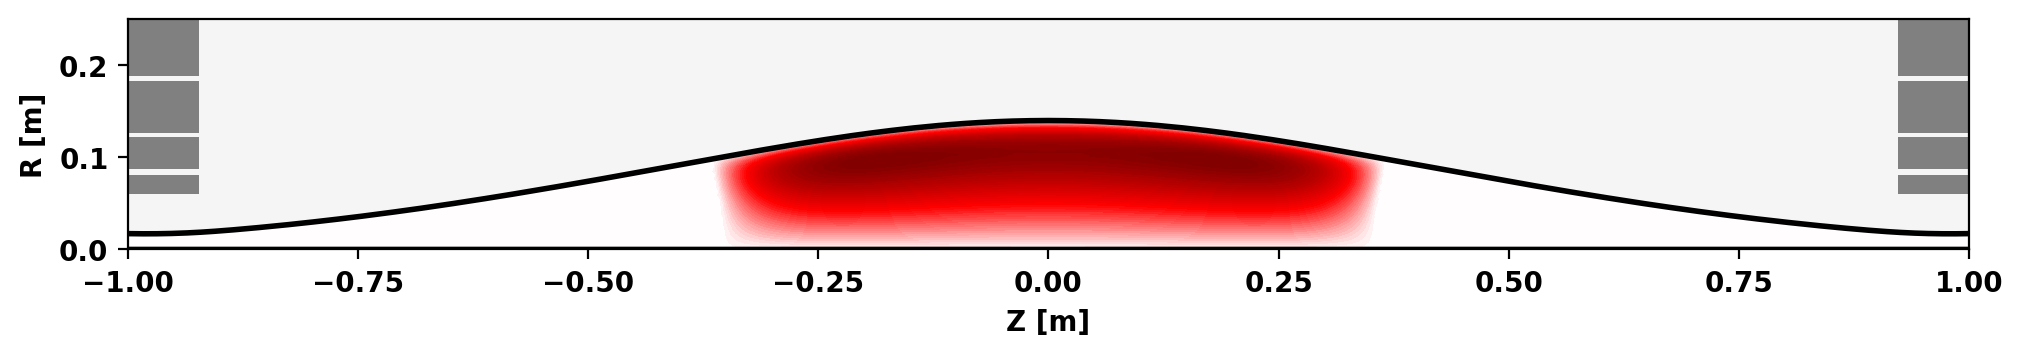

In [11]:
fig, ax = plt.subplots(1,1,sharey=True,figsize=(10,6),constrained_layout=True)
mygs.plot_machine(fig,ax,coil_colormap=None)
curr = EQ_slosh.calc_jtor_plasma()
mask = (mygs.reg == 1)
vmax = (abs(curr)).max()
ax.tricontourf(mygs.r[:,1],mygs.r[:,0],mygs.lc[mask],curr,np.linspace(-vmax,vmax,80),cmap='seismic')
ax.set_ylim(0.0,0.25)
ax.set_xlim(-1.0,1.0)
ax.set_xlabel('Z [m]')
_ = ax.set_ylabel('R [m]')

### Plot pressure
To visualize the pressure we can retrieve the parallel and perpendicular components separately using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker_equilibrium.get_nodal_field "get_nodal_field()".

Starting CG solver
     0  0.000000E+00  0.000000E+00  2.274690E+00
     1 -3.481373E+04  3.424501E+04  2.432181E-01  7.102294E-06
     2 -3.712906E+04  4.241670E+04  1.591448E-02  3.751937E-07
     3 -3.713069E+04  4.244747E+04  2.842921E-03  6.697505E-08
     4 -3.713084E+04  4.245356E+04  1.250093E-03  2.944613E-08
     5 -3.713086E+04  4.245608E+04  3.413502E-04  8.040078E-09
     6 -3.713086E+04  4.245625E+04  1.300565E-04  3.063307E-09
     7 -3.713086E+04  4.245631E+04  4.710979E-05  1.109606E-09
     8 -3.713086E+04  4.245626E+04  1.859029E-05  4.378692E-10
     9 -3.713086E+04  4.245624E+04  6.717678E-06  1.582259E-10
    10 -3.713086E+04  4.245623E+04  2.139400E-06  5.039073E-11
Starting CG solver
     0  0.000000E+00  0.000000E+00  5.494979E+00
     1 -2.635706E+05  1.088125E+05  5.876933E-01  5.400973E-06
     2 -2.810958E+05  1.347664E+05  3.647405E-02  2.706465E-07
     3 -2.811071E+05  1.348231E+05  6.600305E-03  4.895528E-08
     4 -2.811082E+05  1.348319E+05  2.842839E

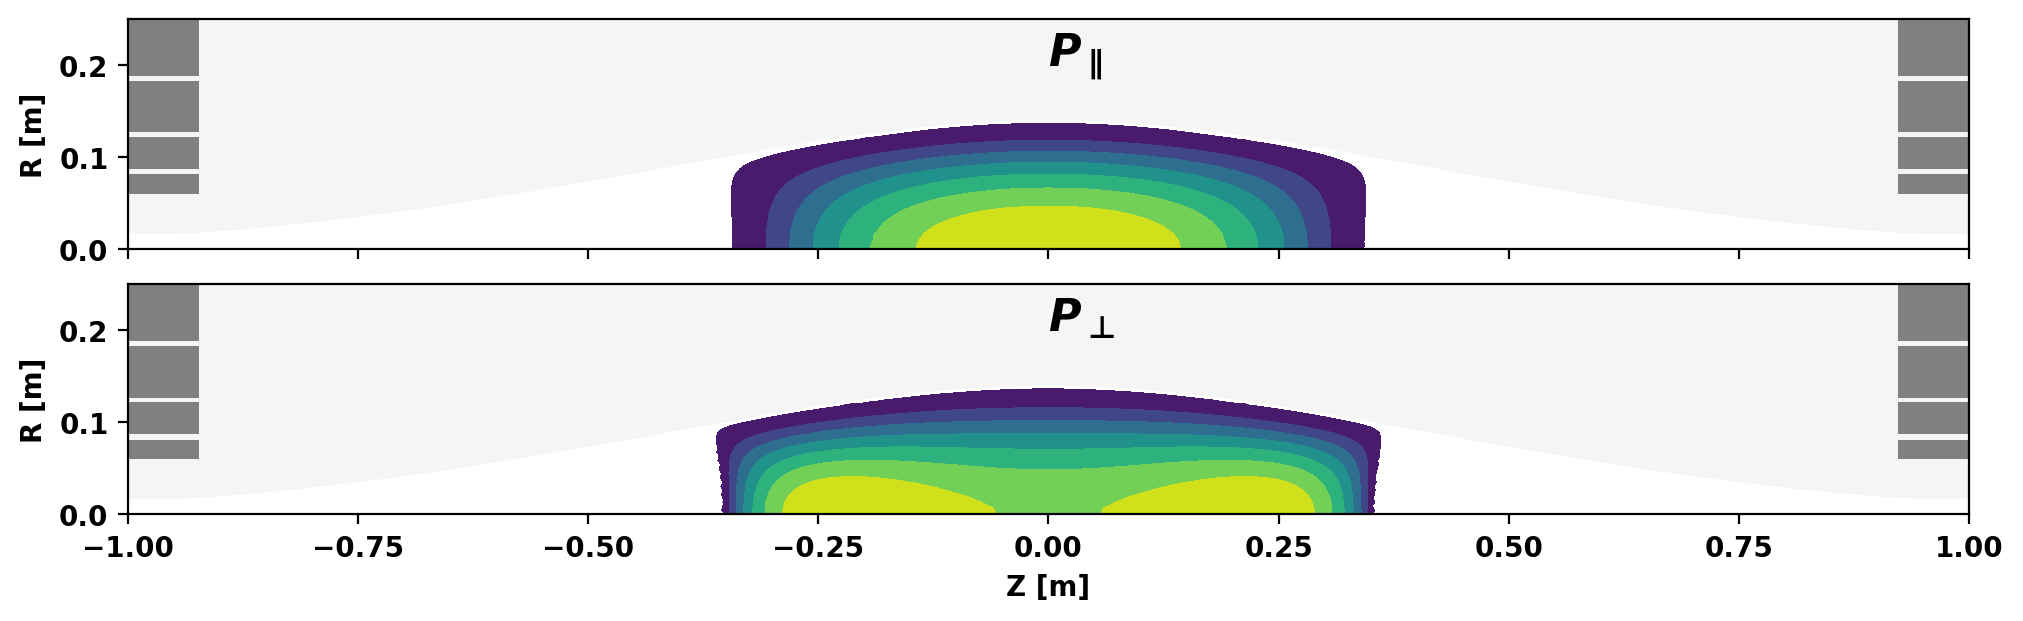

In [12]:
p_parallel = EQ_slosh.get_nodal_field('P_par')
p_par_max = (abs(p_parallel)).max()

p_perp = EQ_slosh.get_nodal_field('P_perp')
p_perp_max = (abs(p_perp)).max()

# Plot pressure components
fig, ax = plt.subplots(2,1,sharey=True,sharex=True,figsize=(10,3),constrained_layout=True)
for ax_tmp in ax:
    mygs.plot_machine(fig,ax_tmp,coil_colormap=None,limiter_color=None)
ax[0].tricontourf(mygs.r[:,1],mygs.r[:,0],mygs.lc[mygs.reg == 1],p_parallel,np.linspace(p_par_max*0.01,p_par_max,8),cmap='viridis')
ax[1].tricontourf(mygs.r[:,1],mygs.r[:,0],mygs.lc[mygs.reg == 1],p_perp,np.linspace(p_perp_max*0.01,p_perp_max,8),cmap='viridis')
for ax_tmp in ax:
    ax_tmp.set_ylim(0.0,0.25)
    ax_tmp.set_xlim(-1.0,1.0)
    ax_tmp.set_ylabel('R [m]')
ax[0].text(0.5, 0.95, r'$P_{\parallel}$', transform=ax[0].transAxes, fontsize=16, verticalalignment='top')
ax[1].text(0.5, 0.95, r'$P_{\bot}$', transform=ax[1].transAxes, fontsize=16, verticalalignment='top')
_ = ax[-1].set_xlabel('Z [m]')